In [ ]:
# CIFAR : 캐나다 고등 연구소 약자
# 10 : 분류 10개
# - 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭
# 이미지 총 6만장. 학습 5만, 테스트 1만
# 크기 32*32

In [1]:
# 데이터 생성, 독립/종속 분리, 훈련/테스트 분리
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 648s 4us/step


In [3]:
# 10가지 분류명(확인용)
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [7]:
# 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
# 콜백
callbacks = [
# 조기 종료
	EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True),
# 최고 성능 모델
	ModelCheckpoint(filepath='best_cifar10_model.keras',monitor='val_accuracy',
    save_best_only=True,verbose=1),
# 학습를 동적 조절
	ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6)
]

In [12]:
# 파이프라인
from tensorflow.data import Dataset
DATASET_SIZE = 50000
TRAIN_SIZE = int(DATASET_SIZE * 0.8)
VAL_SIZE = int(DATASET_SIZE * 0.2)
dataset = Dataset.from_tensor_slices((X_train, y_train))
# 섞음
dataset = dataset.shuffle(buffer_size=DATASET_SIZE)
# 훈련 데이터셋
train_dataset = dataset.take(TRAIN_SIZE)
# 검증 데이터셋
val_dataset = dataset.skip(TRAIN_SIZE)
train_dataset = train_dataset.batch(128).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

In [14]:
# 데이터 증강 : 이미지를 돌리거나, 색상 반전등과 같이 변혈을 한 복사본을 만들어 학습
data_augmentation = tf.keras.Sequential([
	tf.keras.layers.RandomFlip("horizontal"), # 좌우 반전
	tf.keras.layers.RandomRotation(0.2) # 20% 범위내에서 무작위 회전
])

In [15]:
# 모델설계
model = tf.keras.Sequential([
		tf.keras.Input((32, 32, 3)),
		# 데이터 증강
		data_augmentation, #이미지 많게 하는 효과 있습

    # 정규화
    tf.keras.layers.Rescaling(1./255),

    # 블록 1
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),# 속도상승
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # 이때 이미지 크기 16*16

    # 블록 2
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # 이때 이미지 크기 8*8

    # 블록 3
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.GlobalAveragePooling2D(),

    # 분류기
    tf.keras.layers.Dense(10, activation='softmax')
])

In [16]:
# 모델설정
model.compile(optimizer='adam', 
							loss='sparse_categorical_crossentropy',
							metrics=['accuracy']
)

In [34]:
# 학습
history = model.fit(
	train_dataset,
	epochs = 50,
	verbose = 1,
	validation_data=val_dataset,
	callbacks=callbacks,
	batch_size=128,
	)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.6789 - loss: 0.9147
Epoch 1: val_accuracy did not improve from 0.62080
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 294ms/step - accuracy: 0.6772 - loss: 0.9180 - val_accuracy: 0.1213 - val_loss: 4.4941 - learning_rate: 5.0000e-04
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.6795 - loss: 0.9184
Epoch 2: val_accuracy did not improve from 0.62080
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.6785 - loss: 0.9177 - val_accuracy: 0.5660 - val_loss: 1.3940 - learning_rate: 5.0000e-04
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.6857 - loss: 0.8995
Epoch 3: val_accuracy did not improve from 0.62080
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.6869 - loss: 0.9011 - val_accuracy: 0.3833 - val_loss: 2.4719 - learning_rate: 5.0000e-04
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.6940 - loss: 0.8691
Epoch 4: val_accuracy improved from 0.62080 to 0.64

In [35]:
# 평가
_, test_acc = model.evaluate(X_test,y_test)
print(f'정확도 : {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6359 - loss: 1.0971
정확도 : 0.6359000205993652


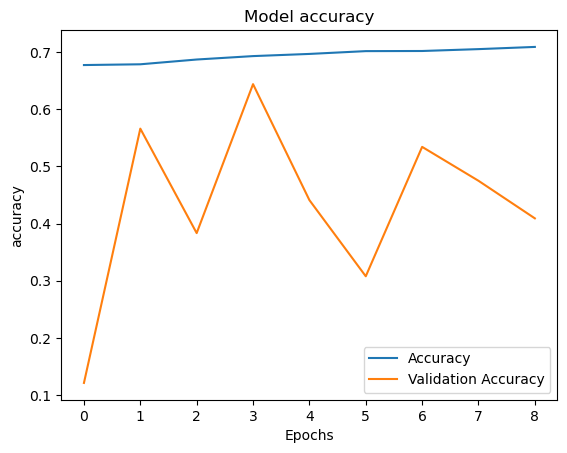

In [36]:
# 성능 시각화
# 평가
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


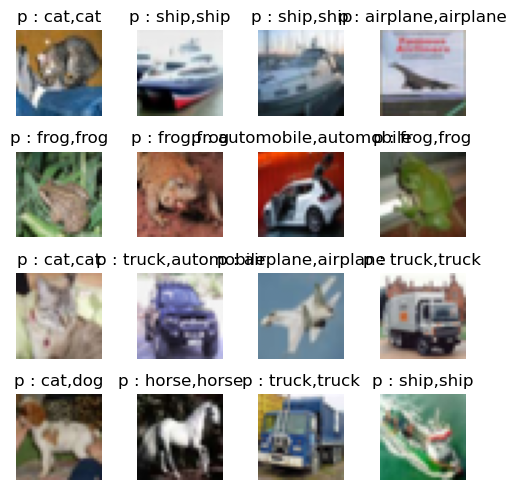

In [37]:
# 이미지 시각화
predictions = model.predict(X_test[:16])
fig, axes = plt.subplots(4, 4, figsize=(5,5))
for i, ax in enumerate(axes.flat):
	ax.imshow(X_test[i])
	predict = predictions[i].argmax()
	true = y_test[i][0]
	ax.set_title(f"p : {class_names[predict]},{class_names[true]}")
	ax.axis('off')
plt.tight_layout()
plt.show()

In [38]:
import cv2
import numpy as np
# 예측
def model_predict_idx(model, img_path):
	img = cv2.imread(img_path, cv2.IMREAD_COLOR)
	# 전처리 하기
	resize_img = cv2.resize(img, (32, 32)) # 테스트 이미지가 28 x 28이 아니기 때문에 크기 변경

	predict = model.predict(np.array([resize_img]))
	result = np.argmax(predict)
	return class_names[result]


In [40]:
result = model_predict_idx(model, '../data/img/cifar10_0_1.JPG')
print(f'airplain? {result}')
result = model_predict_idx(model, '../data/img/cifar10_0_2.JPG')
print(f'dog? {result}')
result = model_predict_idx(model, '../data/img/cifar10_0_3.JPG')
print(f'truck? {result}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
airplain? cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
dog? cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
truck? cat


In [42]:
model2 = tf.keras.models.load_model('best_cifar10_model.keras')
result = model_predict_idx(model2, '../data/img/cifar10_0_1.JPG')
print(f'airplain? {result}')
result = model_predict_idx(model2, '../data/img/cifar10_0_2.JPG')
print(f'dog? {result}')
result = model_predict_idx(model2, '../data/img/cifar10_0_3.JPG')
print(f'truck? {result}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
airplain? airplane
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
dog? ship
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
truck? frog
